In [1]:
import pandas as pd
import numpy as np
import os, ast
os.chdir('..')
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
vdj = pd.read_csv('data/vdj_cleaned_subset_for_MI_no-small-study.csv', index_col = 0)
print(vdj.head())
print(vdj.shape)
epitope_counts = vdj['Epitope'].value_counts()
print(epitope_counts)
epitopes = vdj['Epitope'].unique().tolist()

   Unnamed: 0  complex.id Gene-a           CDR3-a       V-a     J-a  \
0          13          14    TRA    CAYTVLGNEKLTF  TRAV38-1  TRAJ48   
1          14          15    TRA  CAVAGYGGSQGNLIF  TRAV12-2  TRAJ42   
2          15          16    TRA     CAVSFGNEKLTF  TRAV12-2  TRAJ48   
3          16          17    TRA  CAVTHYGGSQGNLIF  TRAV12-2  TRAJ42   
4          17          18    TRA    CAGGGGGADGLTF  TRAV12-2  TRAJ45   

       Species     MHC A MHC B MHC class  ... cdr2a_IMGTgaps cdr2b_IMGTgaps  \
0  HomoSapiens  HLA-A*02   B2M      MHCI  ...     QEAY--KQQN     SYD----VKM   
1  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   
2  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   
3  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   
4  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   

    cdr3a_IMGTgaps   cdr3b_IMGTgaps len_cdr3a len_cdr3b len_cdr3a_IMGTgaps  \
0  CAYTVLG--NEKLTF  

In [3]:
MI = pd.DataFrame()

for ep in epitopes + ['background']:
    df = pd.read_csv('data/output/mutual_info/mutual_info_' + ep + '_endpadding_w_studyspecific_shuffle_wdupl.csv')
    MI = pd.concat([MI, df])

ep  = 'Tanno::A1::naive'
df = pd.read_csv('data/output/mutual_info/mutual_info_' + ep + '_endpadding_wdupl.csv')
MI = pd.concat([MI, df])

In [4]:
print(MI.head())

           Unnamed: 0                                                 25  \
0          ELAGIGILTV  [147.22949467707411, 137.01286256321913, 170.2...   
1  ELAGIGILTV_shuffle  [149.70558498987685, 137.80349669476115, 165.3...   
2          ELAGIGILTV  [0.72477325422831, 0.524101208050448, 0.876309...   
3  ELAGIGILTV_shuffle  [0.7383651771719416, 0.5795529824952437, 0.823...   
4          ELAGIGILTV  [1.804313535190778, 1.7352698378023508, 1.4513...   

                                                  35  \
0  [140.9928202432357, 136.65866540515015, 130.41...   
1  [136.41345592443417, 137.22567449744102, 132.8...   
2  [0.5029940199556298, 0.9013217987335207, 0.671...   
3  [0.5029940199556296, 0.9655886724042415, 0.601...   
4  [1.768751313206483, 1.4104781289921404, 1.5006...   

                                                  50  \
0  [115.4342059824015, 119.92774480049563, 125.56...   
1  [113.50624377300697, 118.6930980509267, 125.17...   
2  [0.6957509182433519, 0.658058219707

In [5]:
MI.columns

Index(['Unnamed: 0', '25', '35', '50', '80', '100', '150', '200', '300', '374',
       'type', '500', '1000', '1500', '1853', '348', '342', '349', '196',
       '331', '235', '226', '98', '125', '1699', '704', '1200', '412', '243',
       '133', '127', '177', '124', '242', '175', '2000', '2500', '3000',
       '5000', '9713', '10000', '14742'],
      dtype='object')

In [6]:
MI = MI.set_index(['type', 'Unnamed: 0'])
MI.columns = [int(x) for x in MI.columns]
MI = MI.sort_index(axis=1)
# print(MI)

In [7]:
MI1 = MI.dropna(axis=0, how='all')
MI1 = MI1.replace(pd.NA, '[]')

In [8]:
for c in MI1.columns:
    MI1[c] = [ast.literal_eval(x) for x in MI1[c]]
    MI1[c] = [x if type(x) == list else [x]*10 for x in MI1[c]]
# print(MI1)

In [9]:
MI1 = MI1.reset_index(names = ['type','epitope'])
MI1['shuffle'] = ['shuffle' if 'shuffle' in x else 'real' for x in MI1['epitope']]
MI1['epitope'] = [x.split('_')[0] for x in MI1['epitope']]
# print(MI1)

In [10]:
MI2 = MI1.set_index(['epitope', 'shuffle', 'type']).apply(pd.Series).stack().explode()
MI2 = MI2.reset_index().rename(columns = {'level_3':'subsample', 0:'value'}).dropna(subset='value')

In [11]:
MI2['1/N'] = 1/MI2['subsample']

In [12]:
def fit_linear(mydf, title, ax):    
    single_vals = []
    def _fit(mydf1):
        df = mydf1.copy()
        df = df.dropna(subset=['value'])
        x = np.array(df['1/N'])
        myfit = np.polyfit(x, df['value'].astype('float64'), deg=1)
        p = np.poly1d(myfit)
        x_unique = np.linspace(0, max(x))
        y_unique = p(x_unique)
        # print(p, x_unique, y_unique)
        # print(x, df['value'].astype('float64'))
        assert p(0) == myfit[1]
        return(x_unique, y_unique, p(0))
    
    for j in ['real', 'shuffle']:
        if j == 'real':
            linestyle = '-'
            marker = 'o'
            s = 30
            col='r'
        else:
            linestyle = '-'
            marker = 'X'
            s = 30
            col='k'
        mydf0 = mydf.loc[mydf.shuffle == j]
        x_unique, y_unique, single_val = _fit(mydf0)    
        xy = pd.DataFrame([x_unique, y_unique], index = ['x', 'y']).T
        sns.scatterplot(data = mydf0, x = '1/N', y='value', ax=ax, alpha = 0.5, marker = marker, c=col, s = s, legend=None)
        sns.lineplot(data=xy, x='x', y='y', color = col, linestyle = linestyle, alpha = 0.5,  label = j, ax=ax)
        single_vals.append(single_val)
        # ax.scatter(0, single_val, marker = marker, color = col, s = 300, alpha = 0.5)
    ax.set_title(title)
    ax.set_xlim(0,0.041)
    # ax.set_yscale('log')
    # ax.set_xscale('log')

    return(single_vals)

In [13]:
def fit_nonlinear(mydf, title, ax):    
    single_vals = []
    def _fit(mydf1):
        df = mydf1.copy()
        df = df.dropna(subset=['value'])
        x = np.array(df['1/N'])
        myfit = np.polyfit(np.log10(x), df['value'].astype('float64'), deg=2)
        # print(myfit)
        p = np.poly1d(myfit)
        x_unique = np.linspace(0, max(x),100)
        y_unique = p(np.log10(x_unique))
        print(p, x_unique, y_unique)
        # print(x, df['value'].astype('float64'))
        assert p(0) == myfit[-1]
        return(x_unique, y_unique, myfit[-1])
    
    for j in ['real', 'shuffle']:
        if j == 'real':
            linestyle = '-'
            marker = 'o'
            s = 30
            col='r'
        else:
            linestyle = '-'
            marker = 'X'
            s = 30
            col='k'
        mydf0 = mydf.loc[mydf.shuffle == j]
        x_unique, y_unique, single_val = _fit(mydf0)    
        xy = pd.DataFrame([x_unique, y_unique], index = ['x', 'y']).T
        print(xy)
        sns.scatterplot(data = mydf0, x = '1/N', y='value', ax=ax, alpha = 0.5, marker = marker, c=col, s = s, legend=None)
        sns.lineplot(data=xy, x='x', y='y', color = col, linestyle = linestyle, alpha = 0.5,  label = j, ax=ax)
        single_vals.append(single_val)
        # ax.scatter(0, single_val, marker = marker, color = col, s = 300, alpha = 0.5)
    ax.set_title(title)
    ax.set_xlim(0,0.041)
    # ax.set_yscale('log')
    # ax.set_xscale('log')

    return(single_vals)
    

In [ ]:
f2 = 'data/output/figures/'

(64200, 6)
['cdr3a-cdr3b', 'Va-Vb', 'Ja-Jb', 'Va-Ja', 'Vb-Jb', 'Va-Jb', 'Vb-Ja', 'Va-CDR3a', 'Vb-CDR3b', 'Ja-CDR3a', 'Jb-CDR3b', 'Va-CDR3b', 'Vb-CDR3a', 'Ja-CDR3b', 'Jb-CDR3a']
(64200, 6)
ASNENMETM


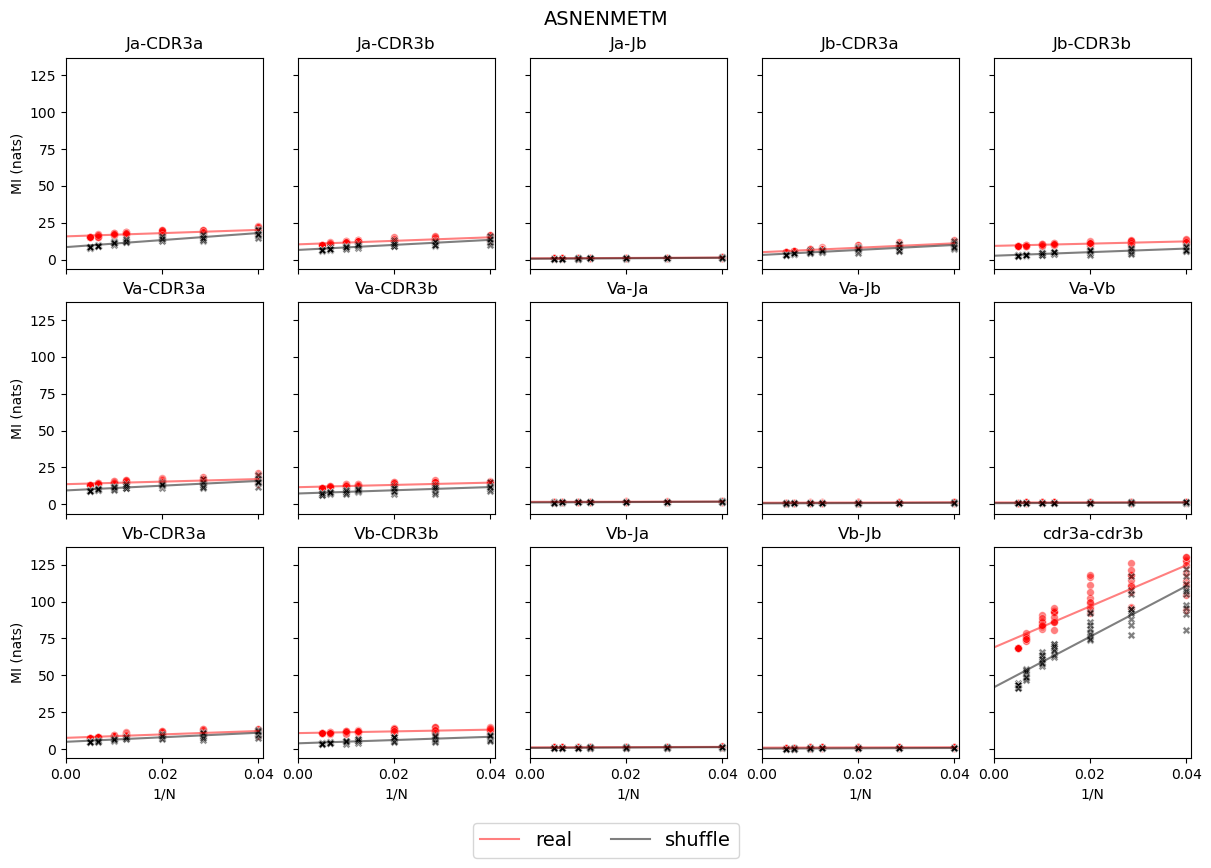

ATDALMTGF


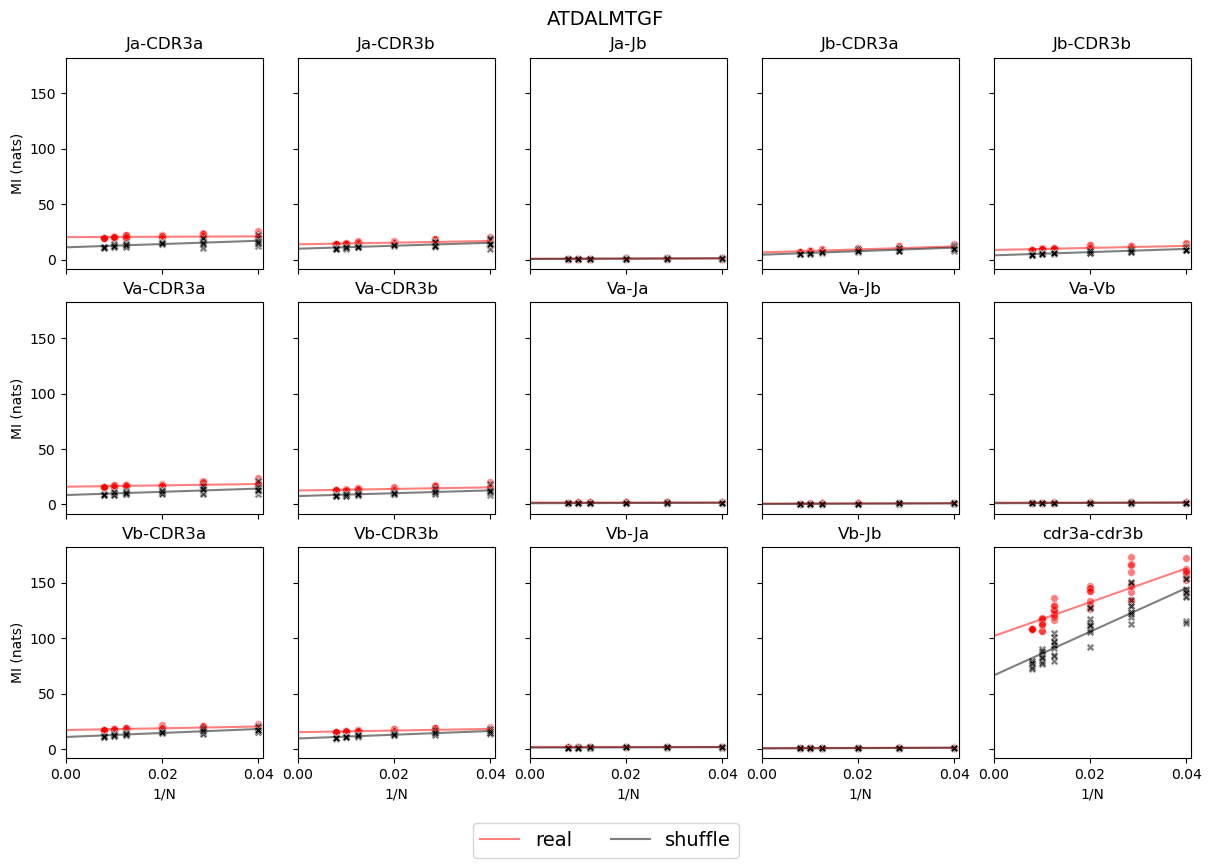

AVFDRKSDAK


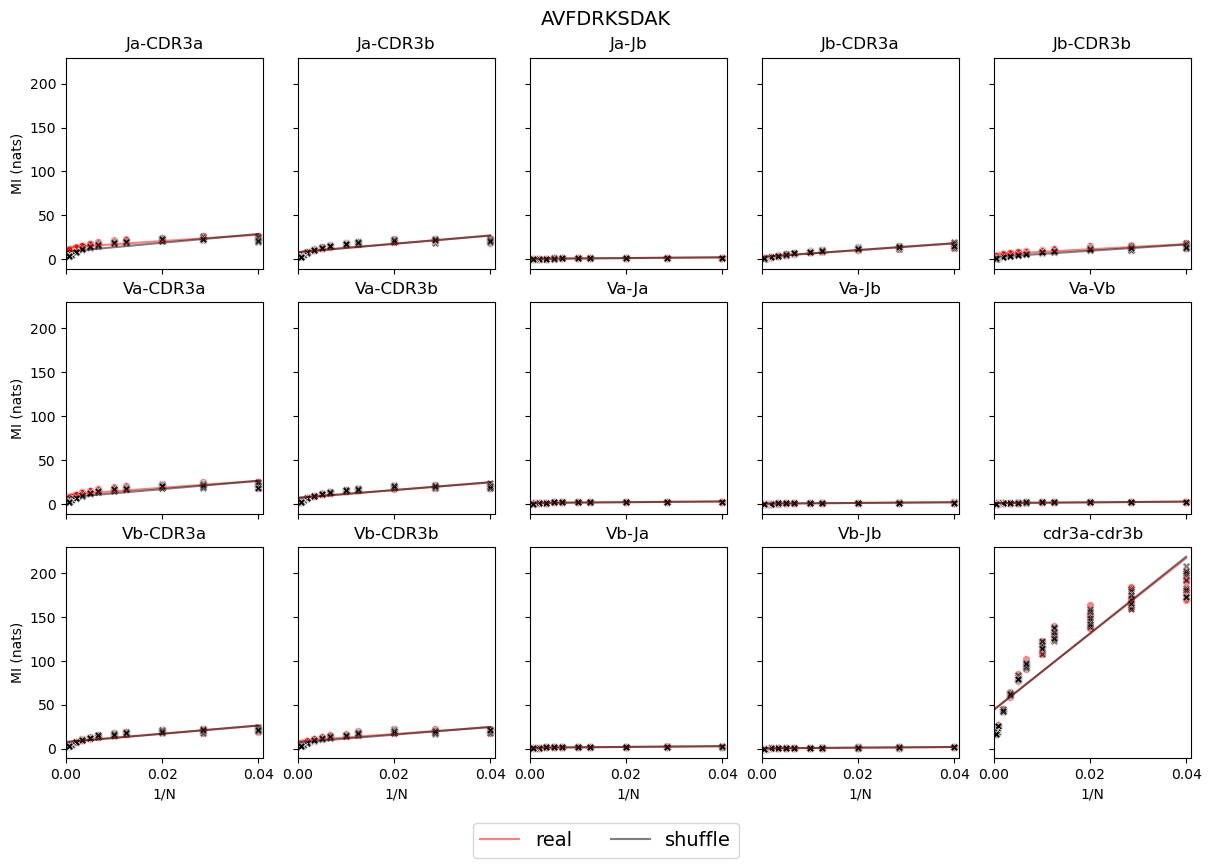

CINGVCWTV


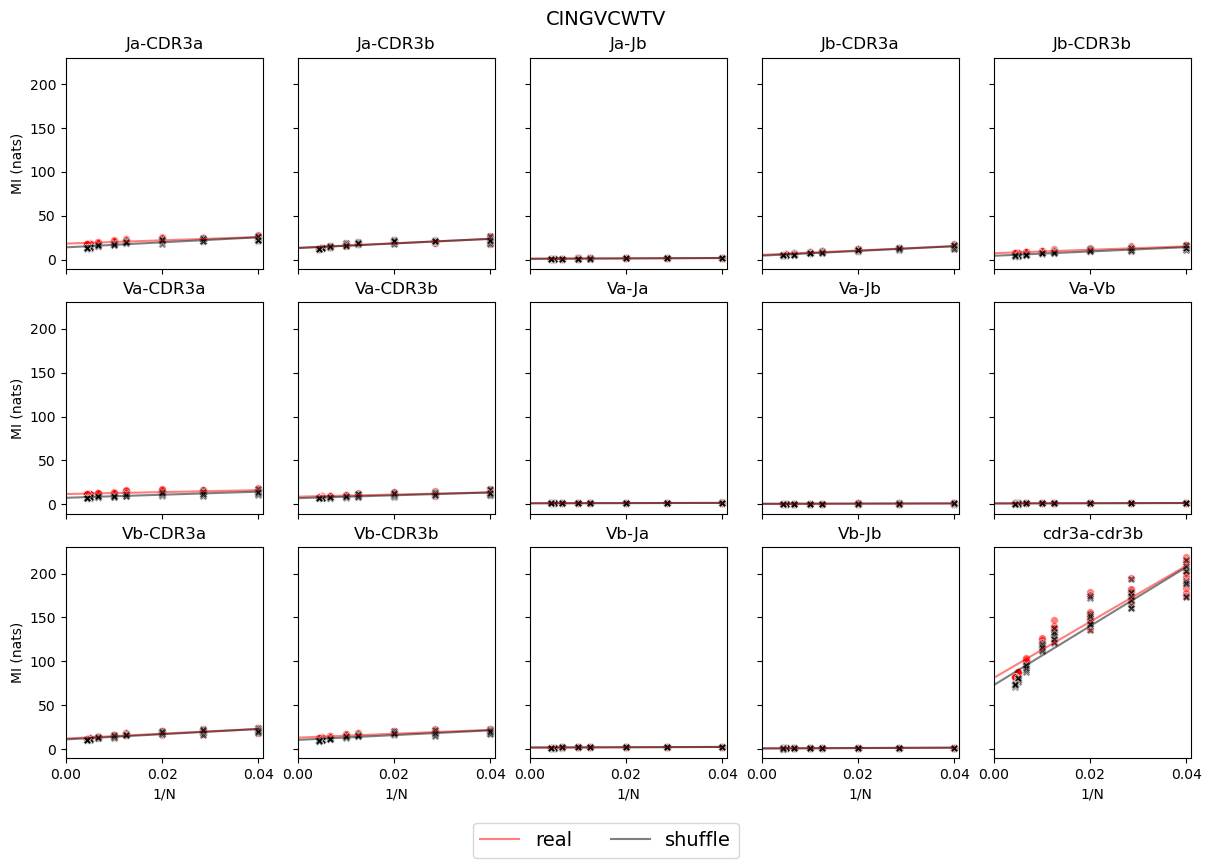

ELAGIGILTV


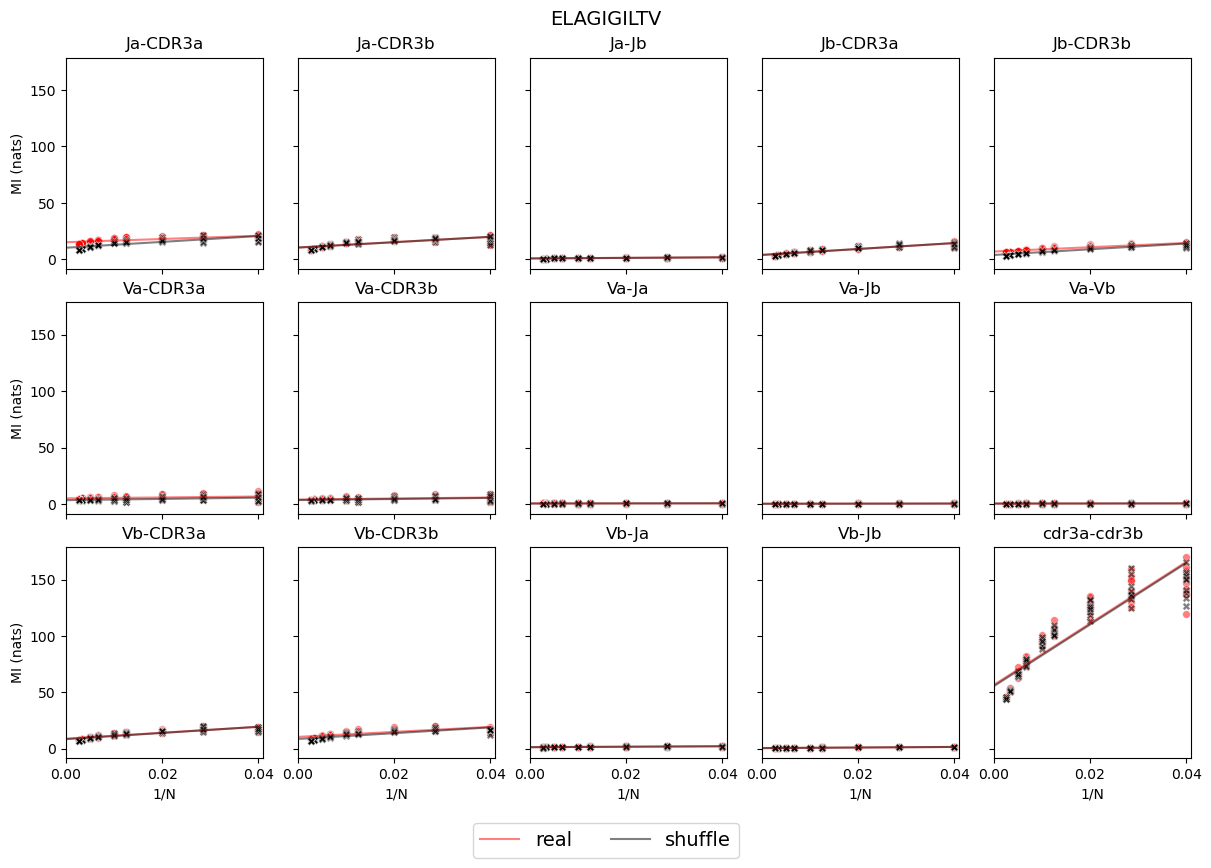

GILGFVFTL


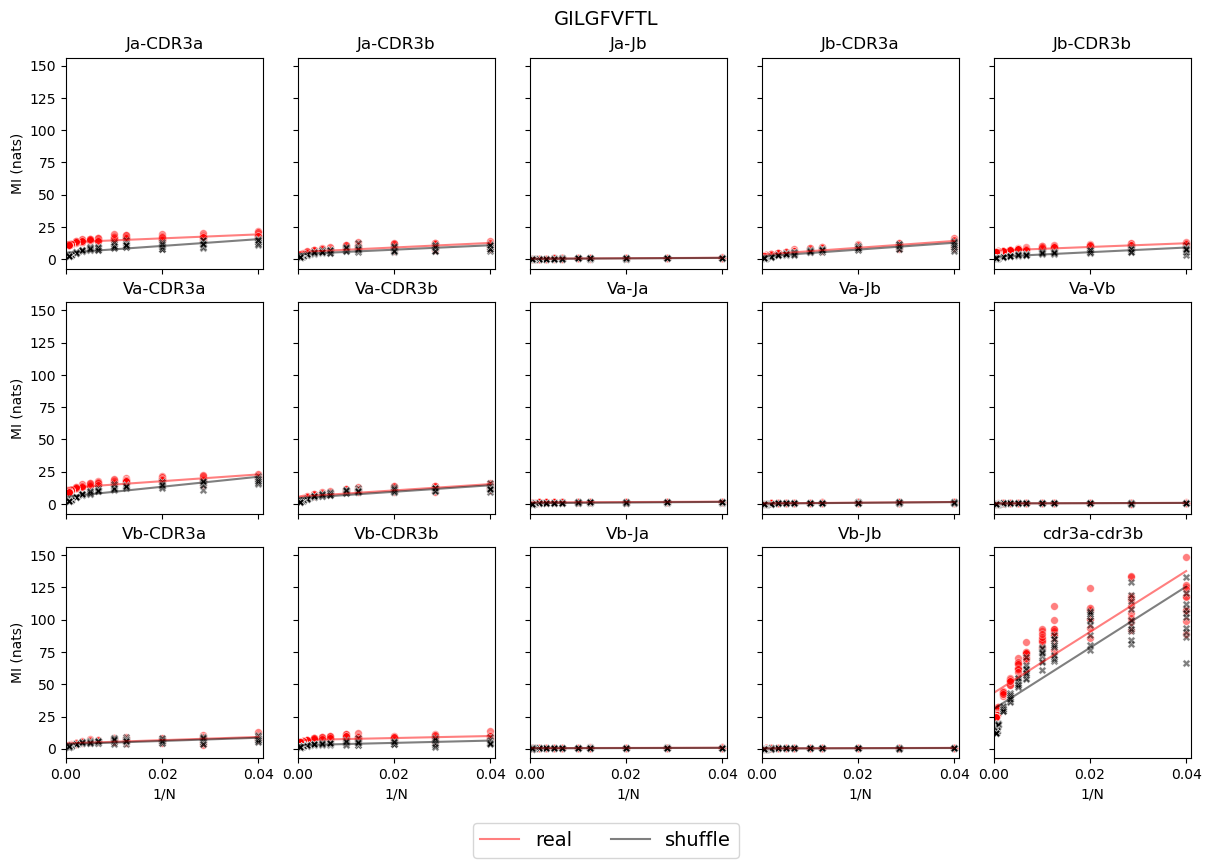

GLCTLVAML


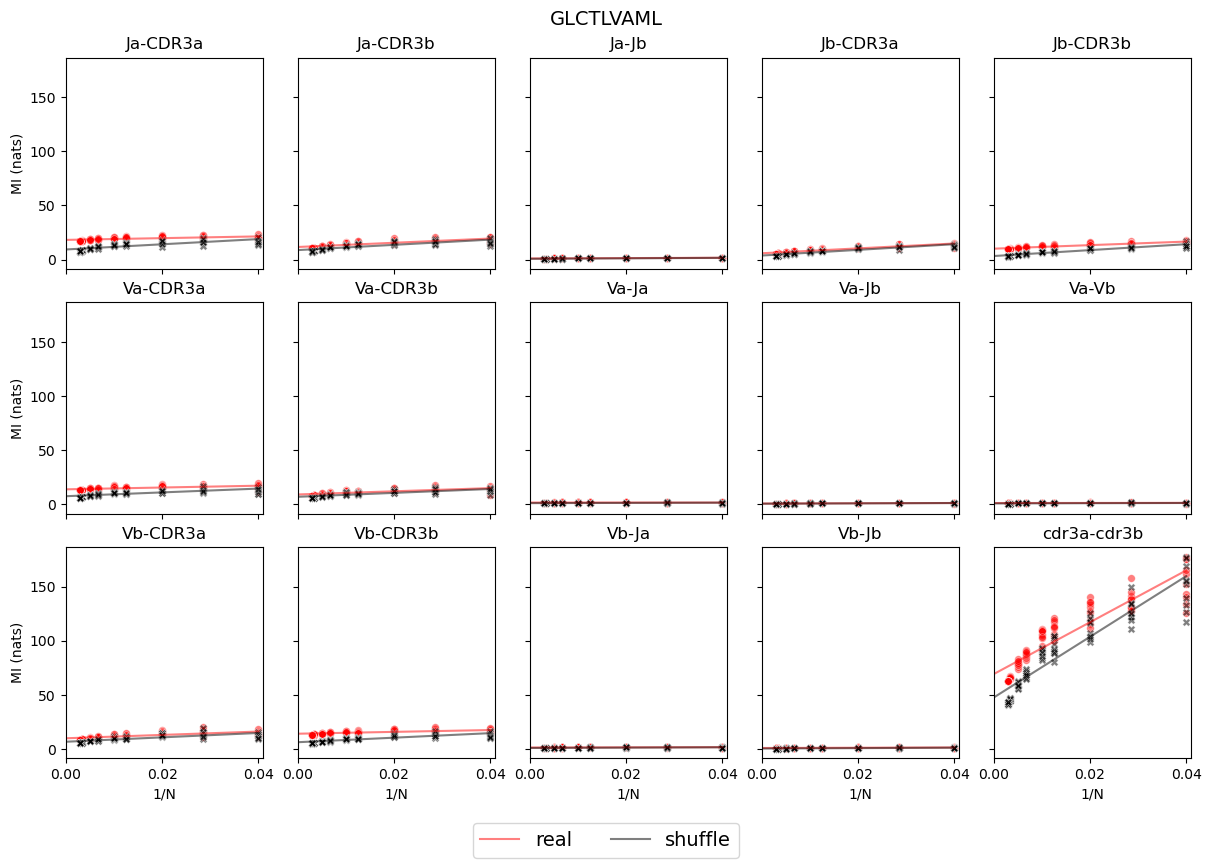

HGIRNASFI


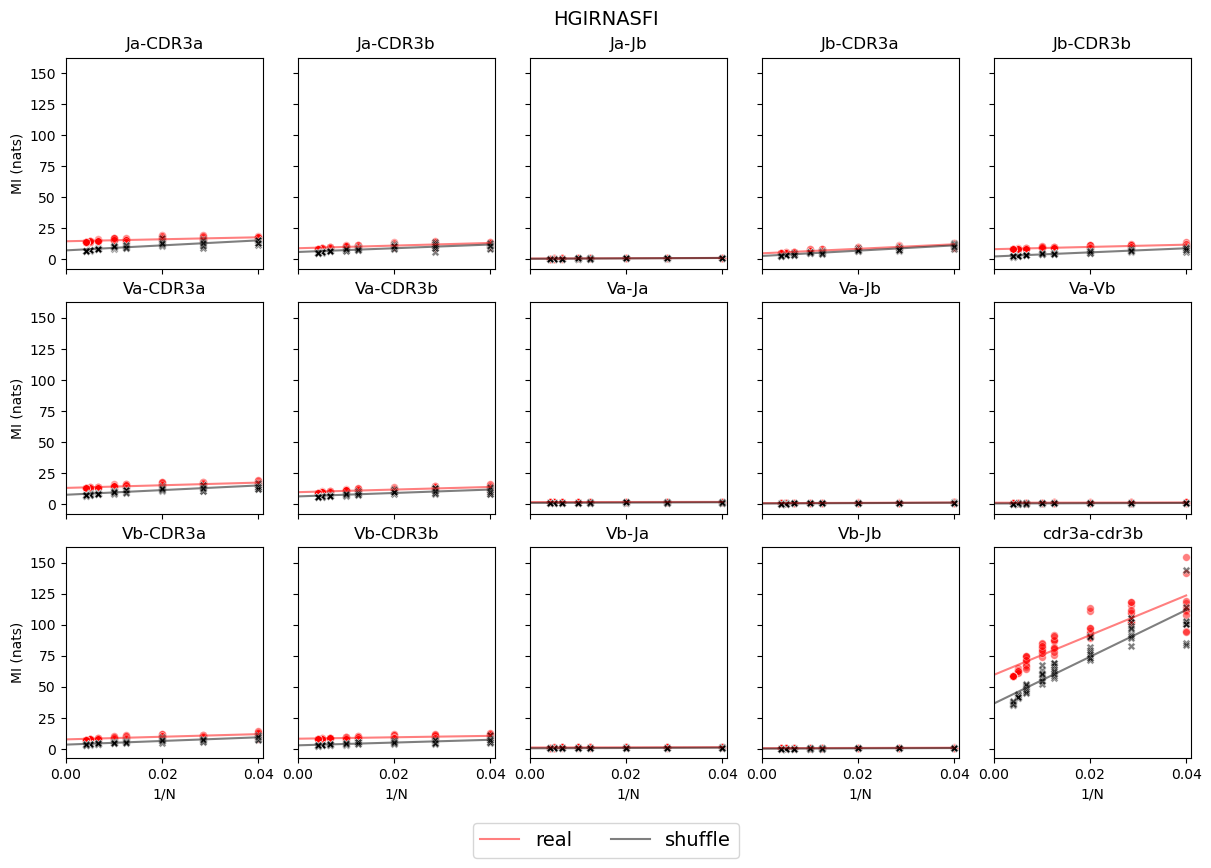

IVTDFSVIK


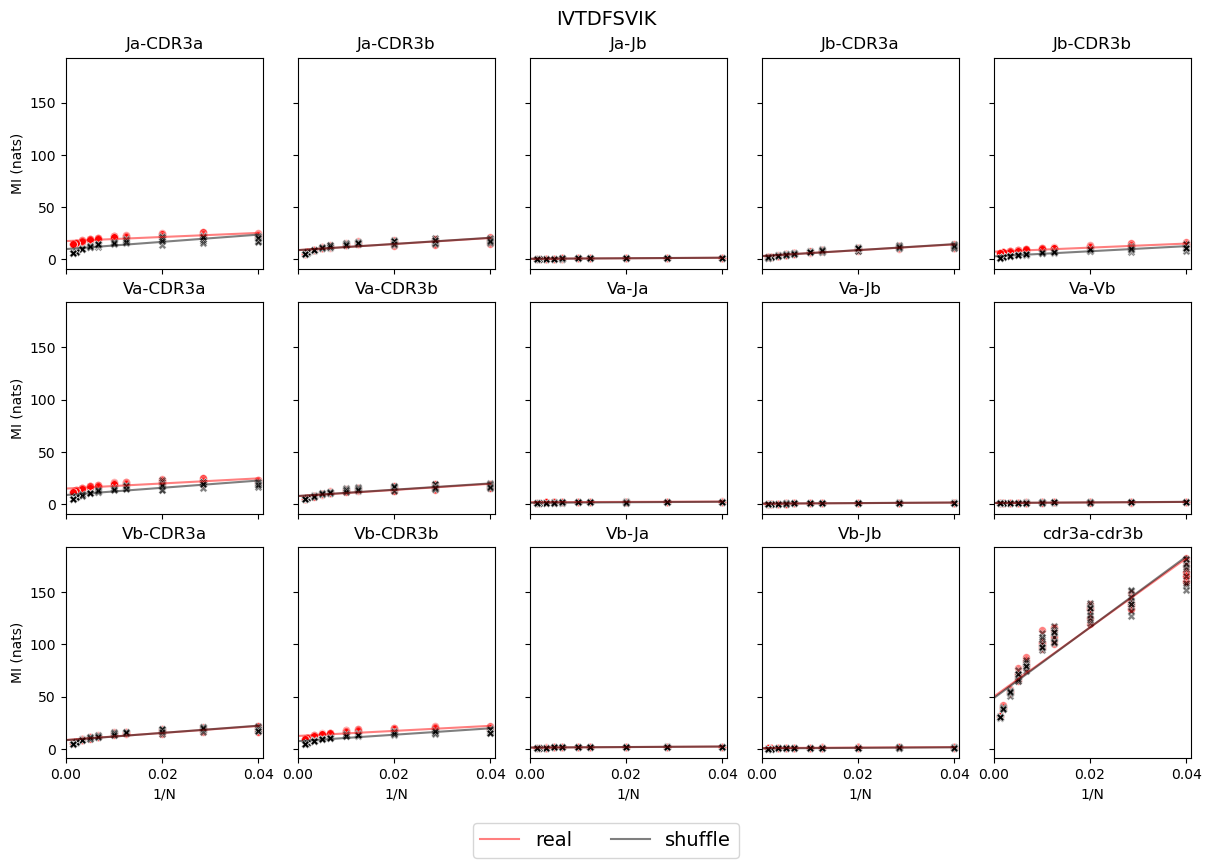

KSKRTPMGF


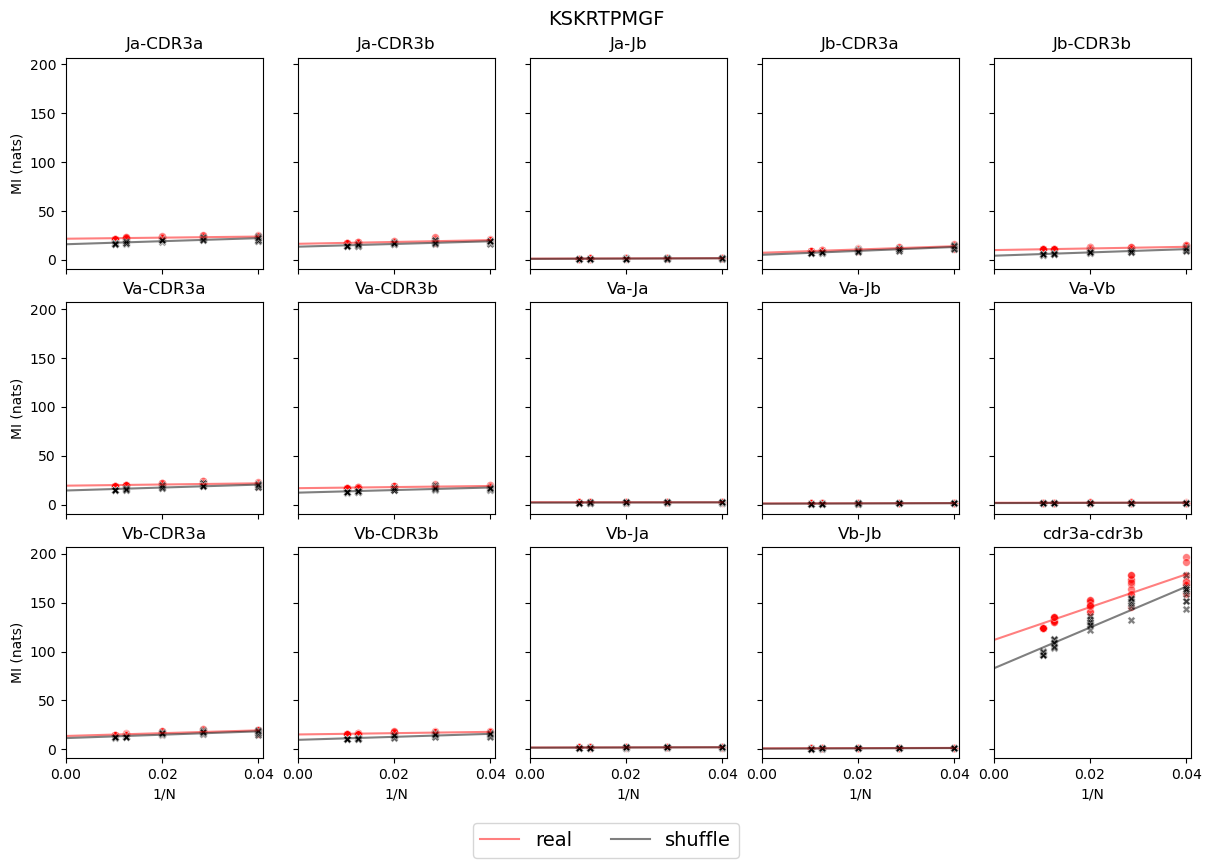

LLWNGPMAV


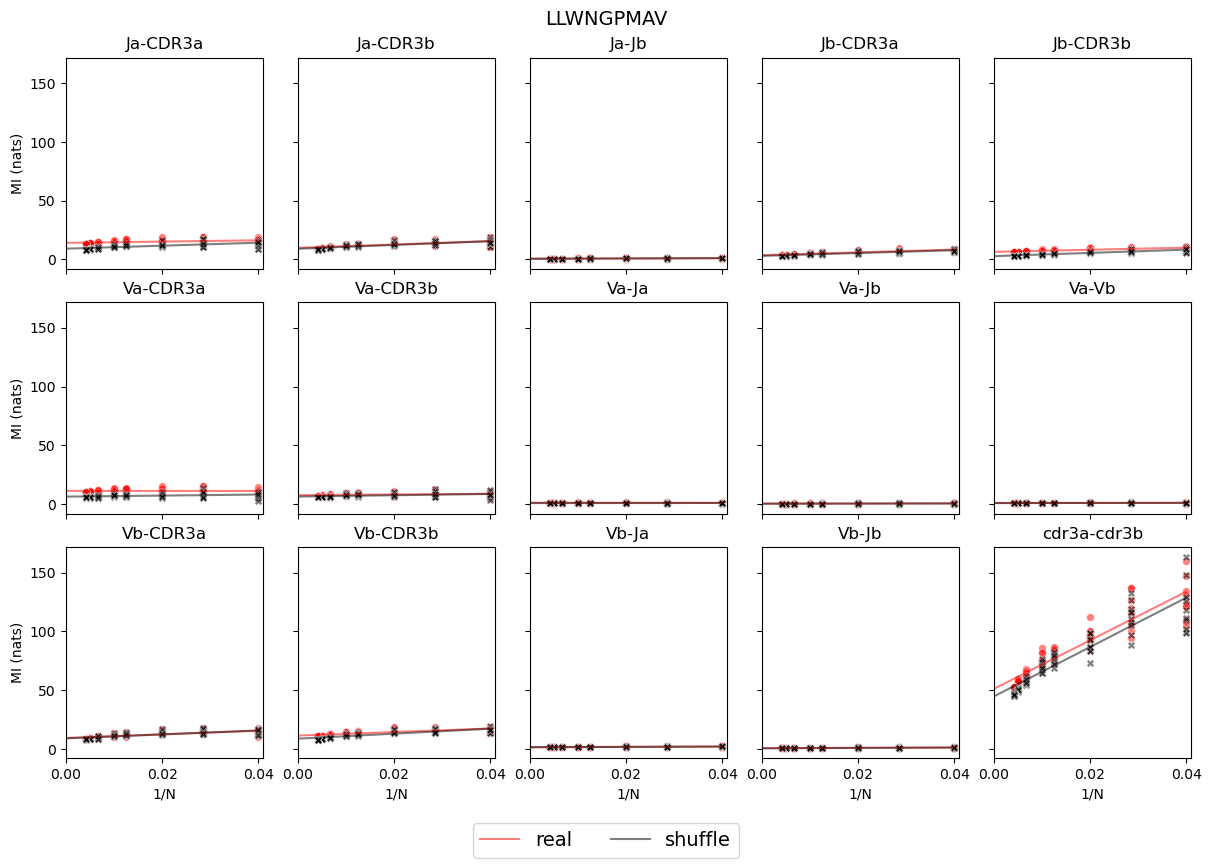

LSLRNPILV


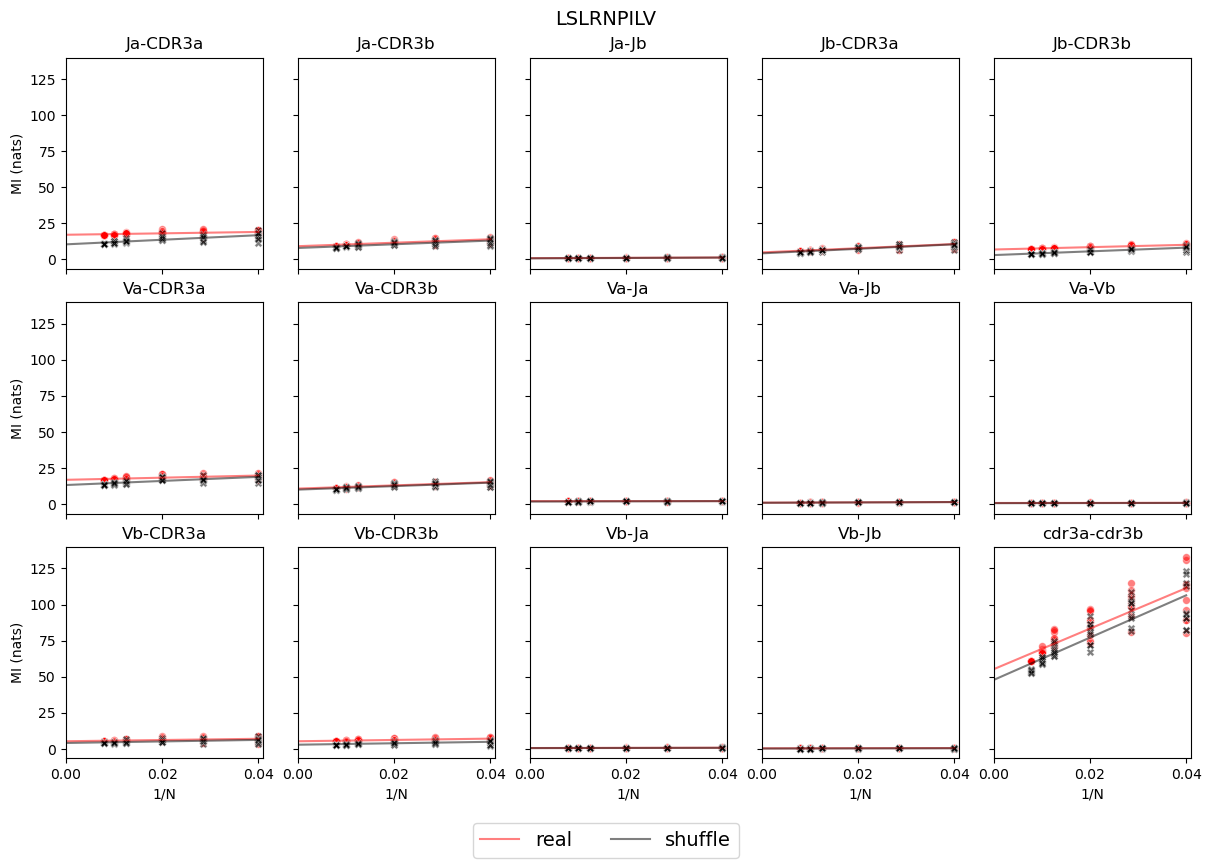

LTDEMIAQY


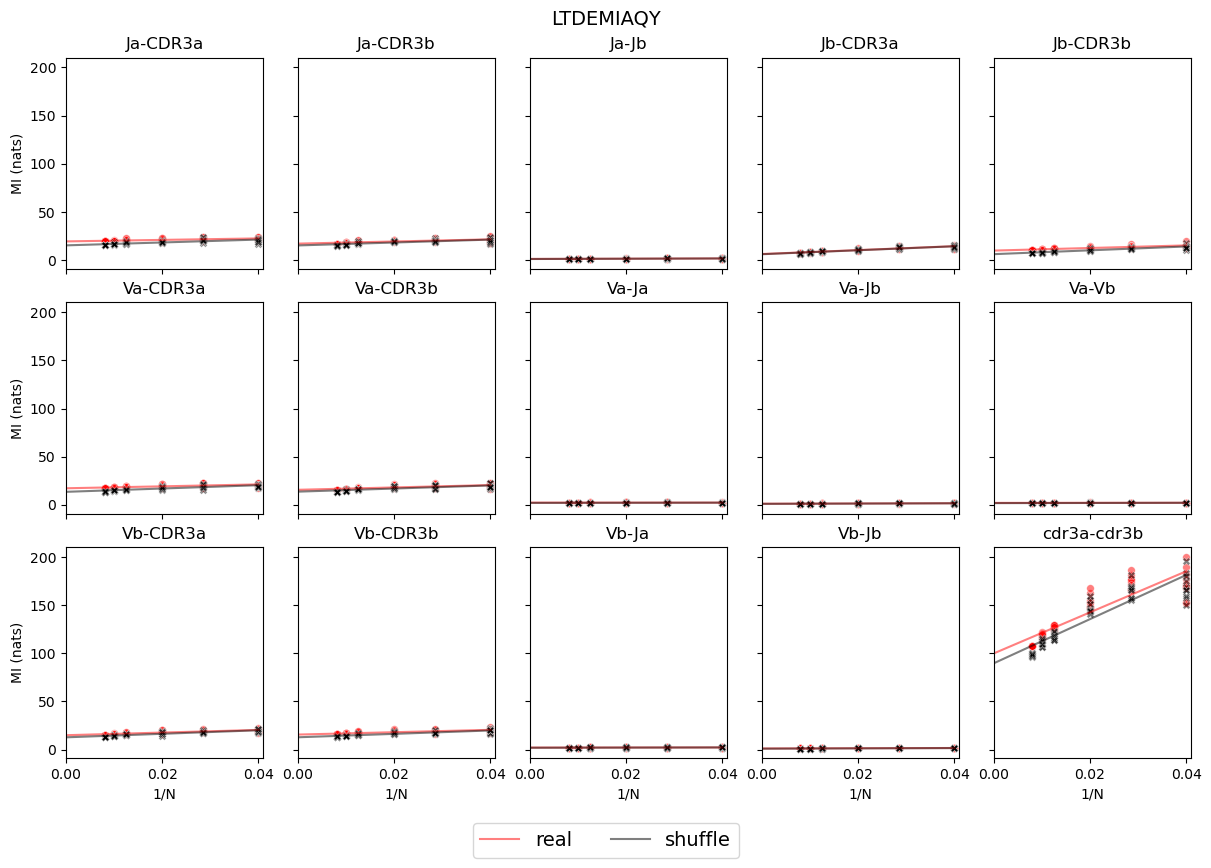

NLVPMVATV


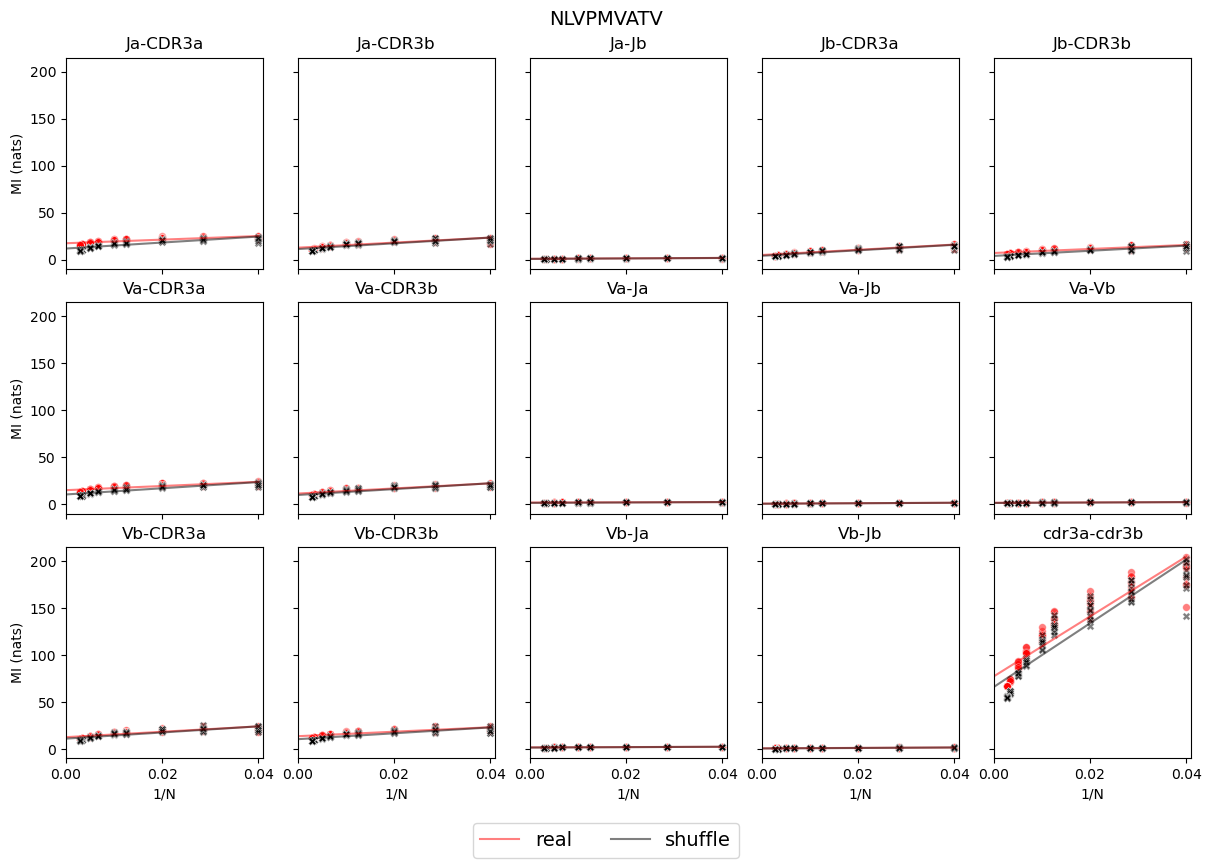

RAKFKQLL


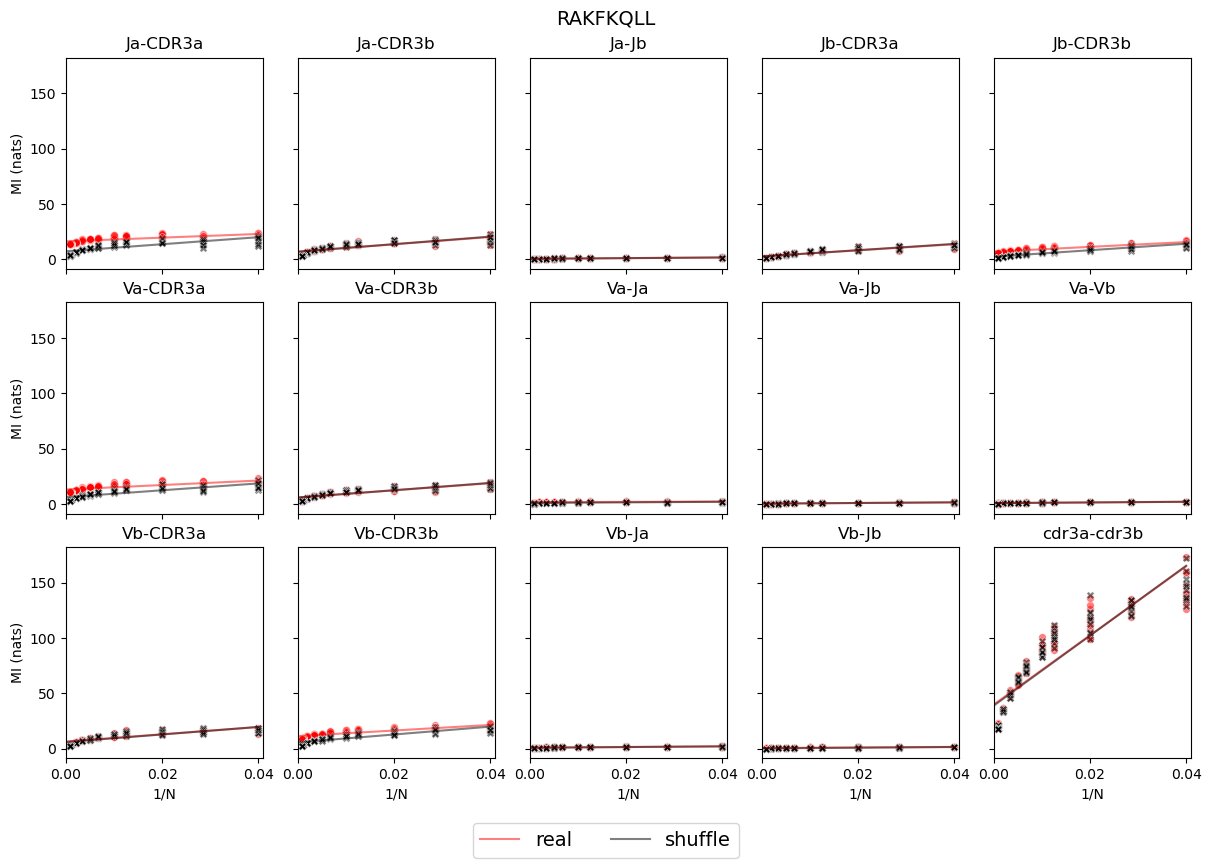

RLRAEAQVK


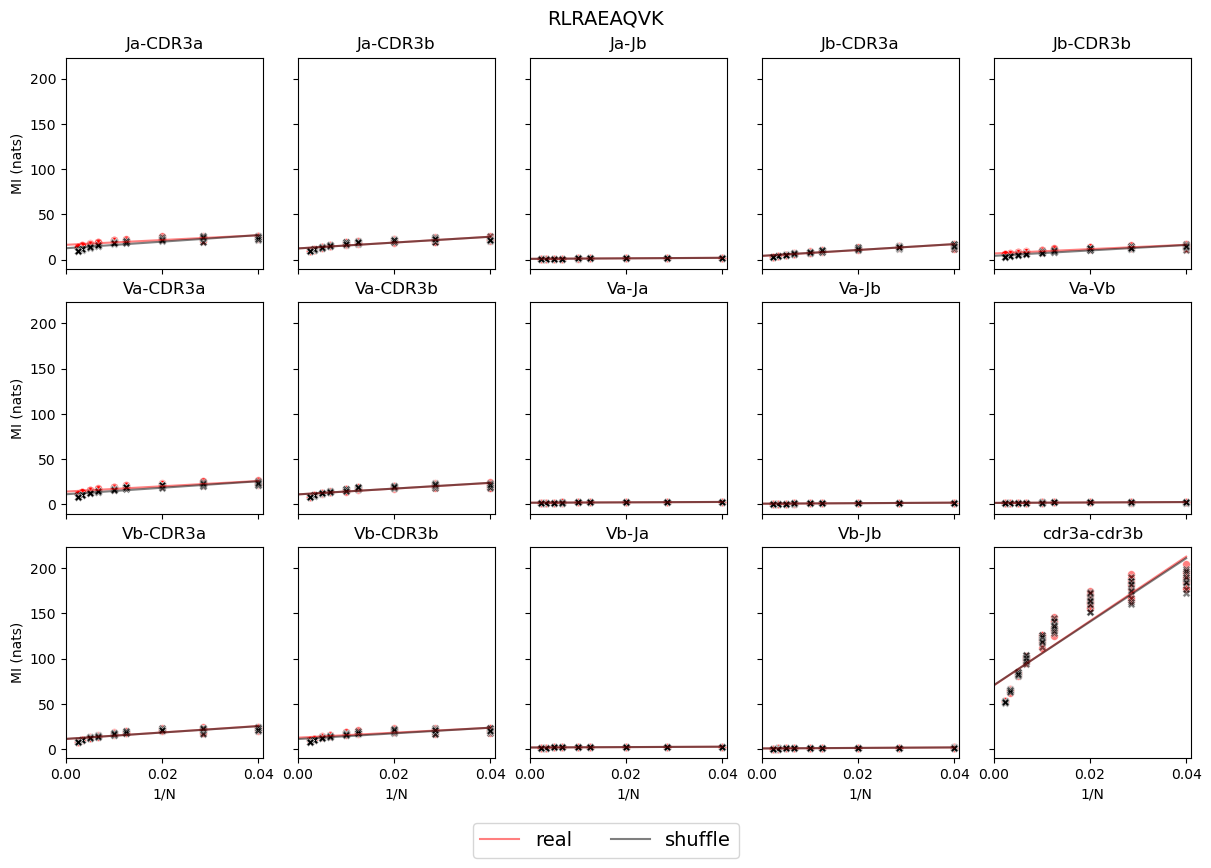

SPRWYFYYL


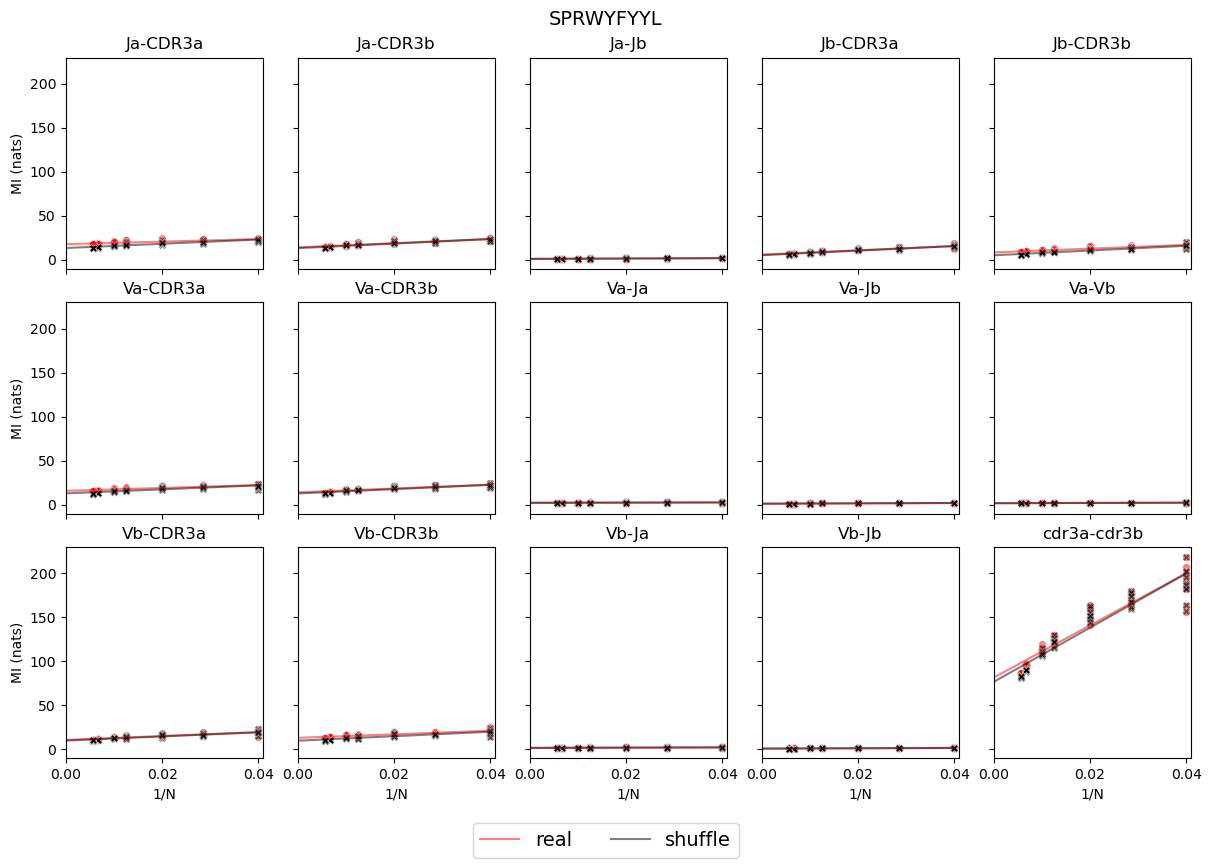

SSLENFRAYV


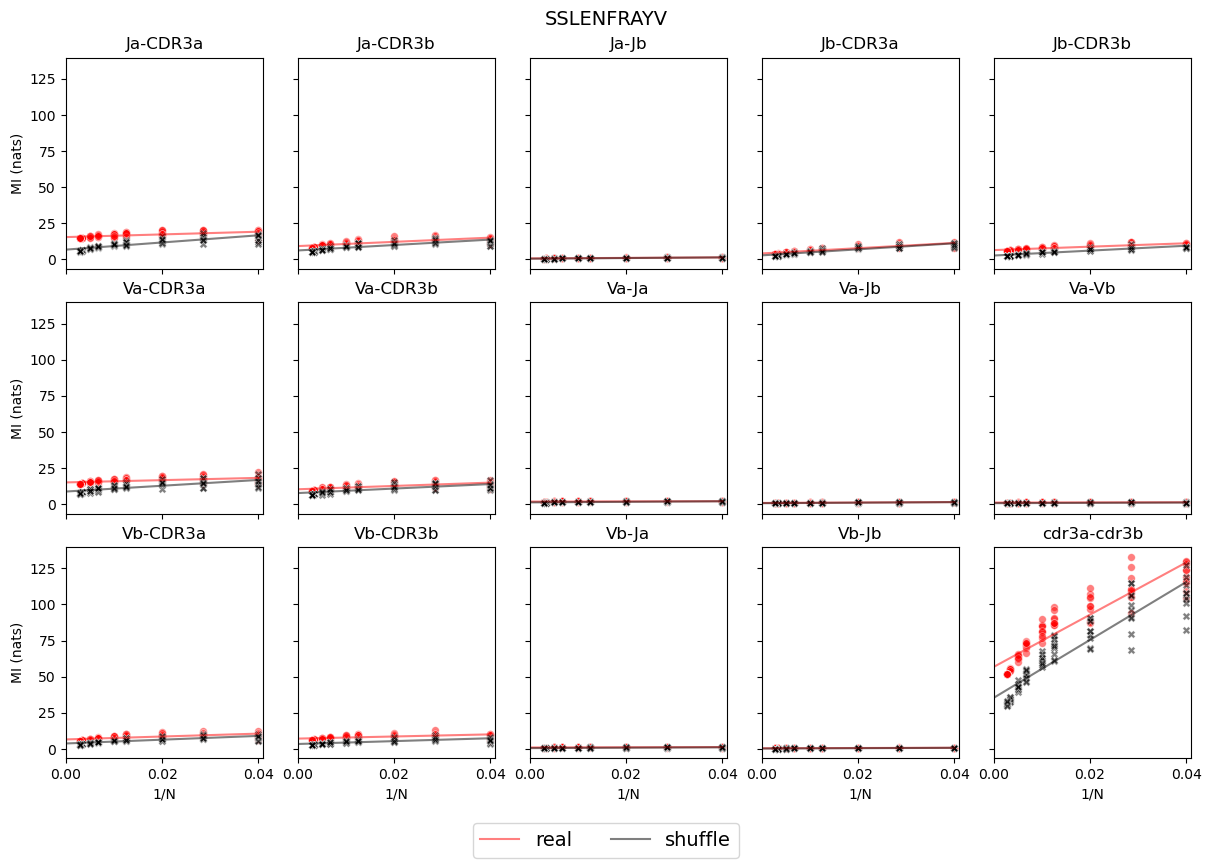

SSPPMFRV


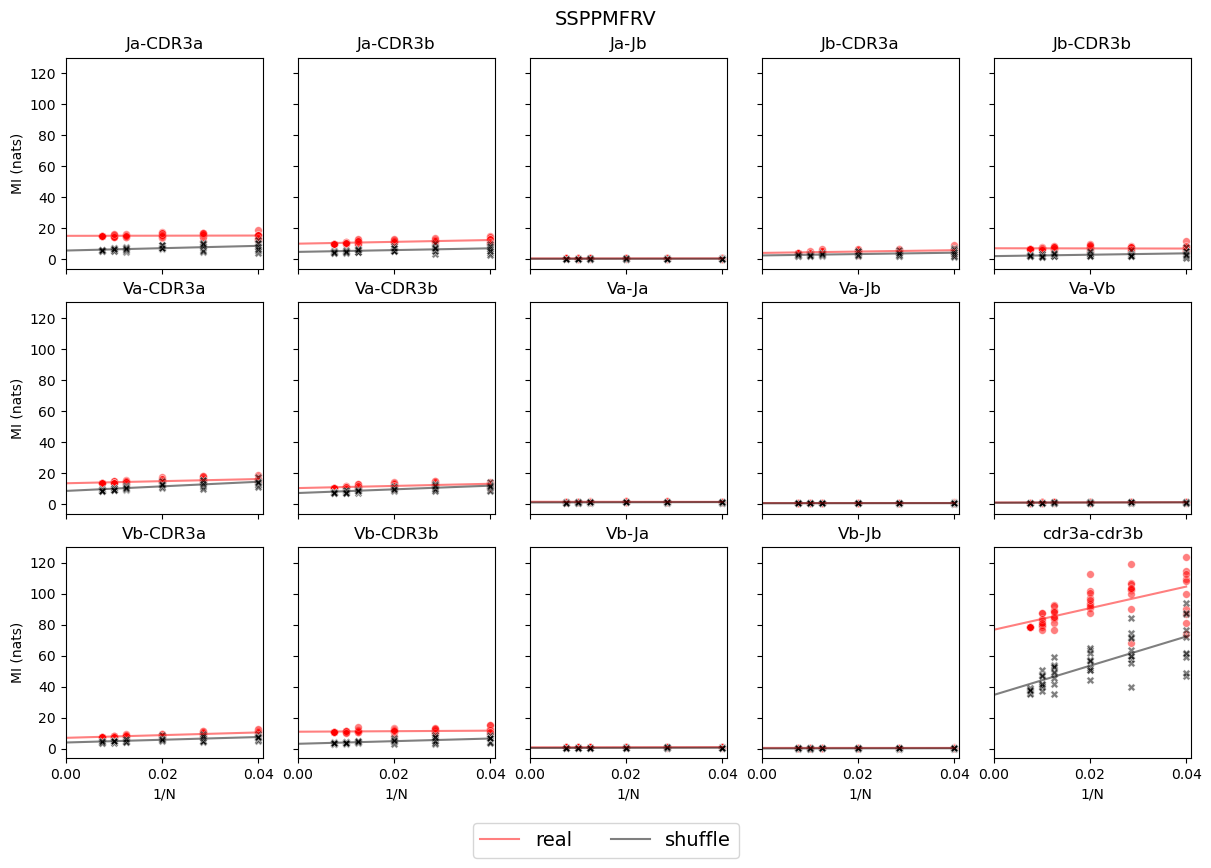

SSYRRPVGI


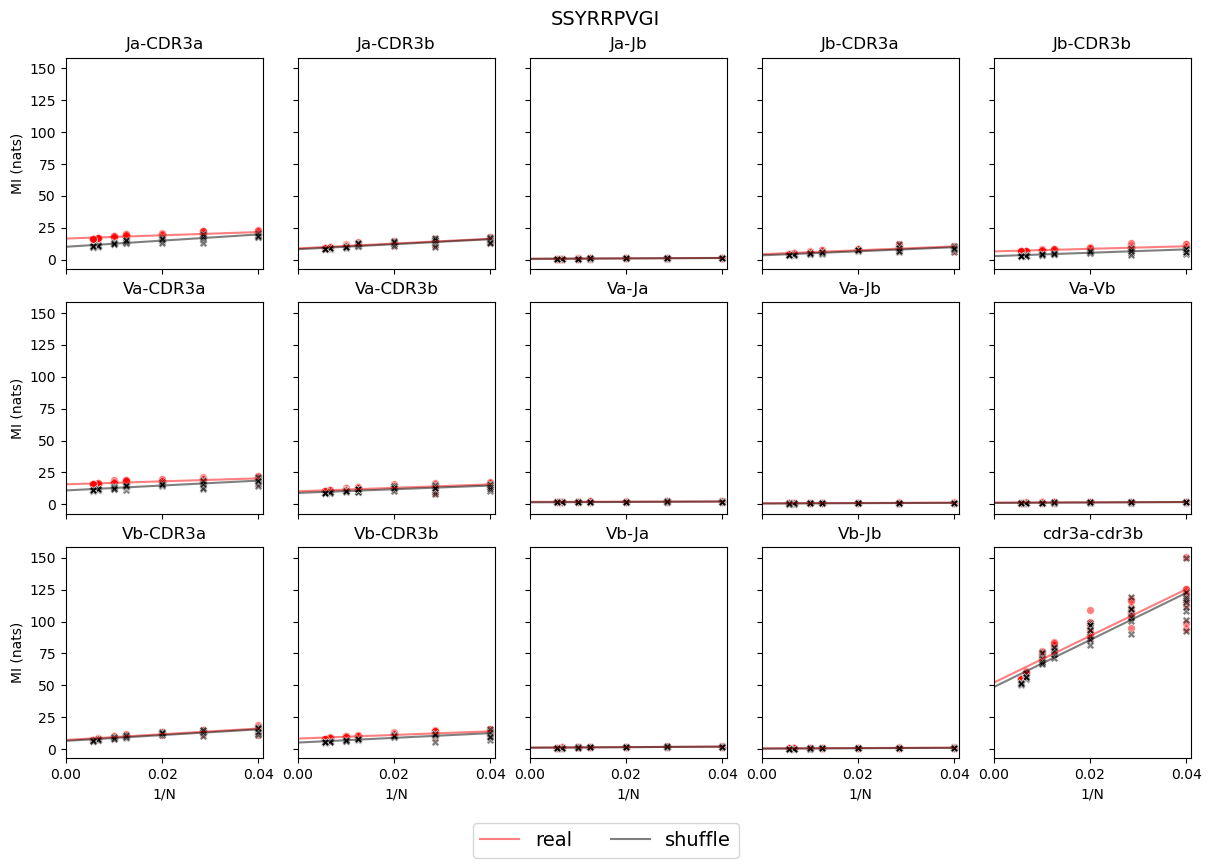

TTDPSFLGRY


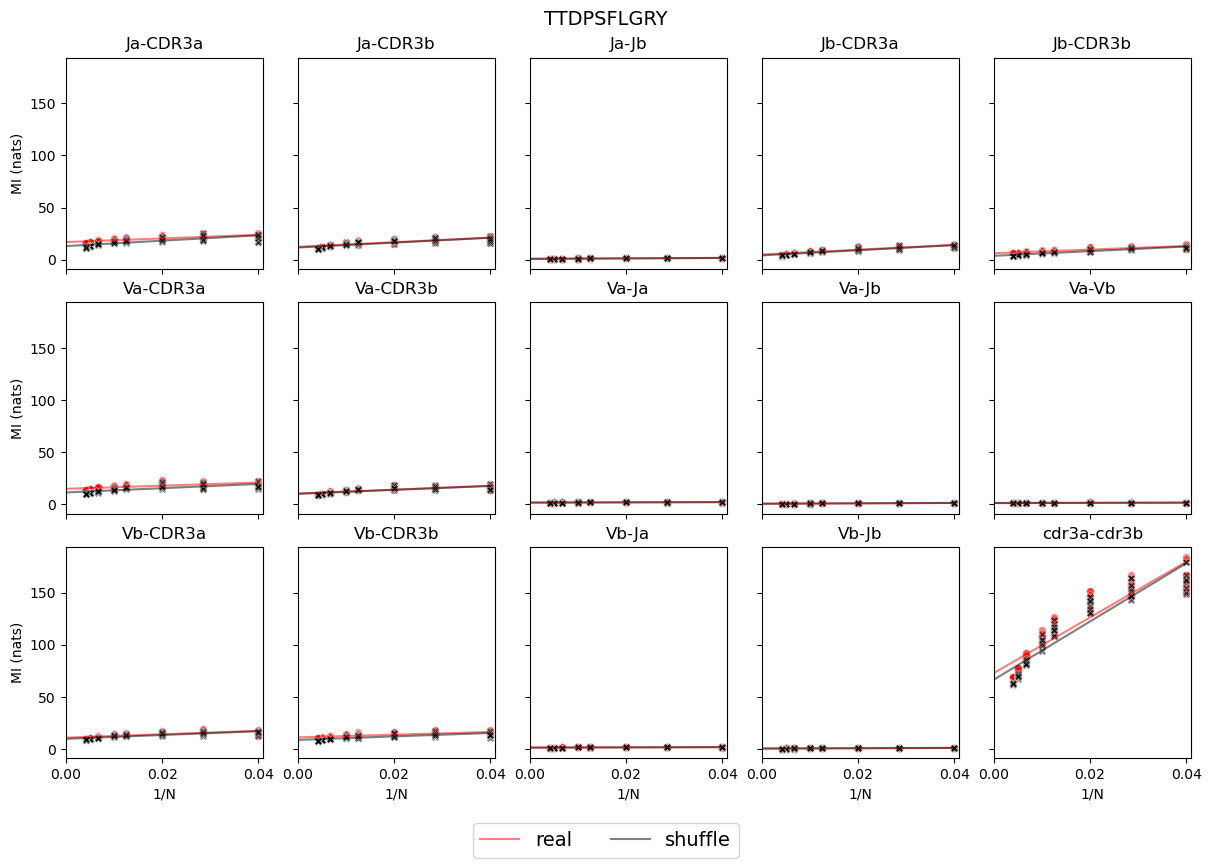

Tanno::A1::naive


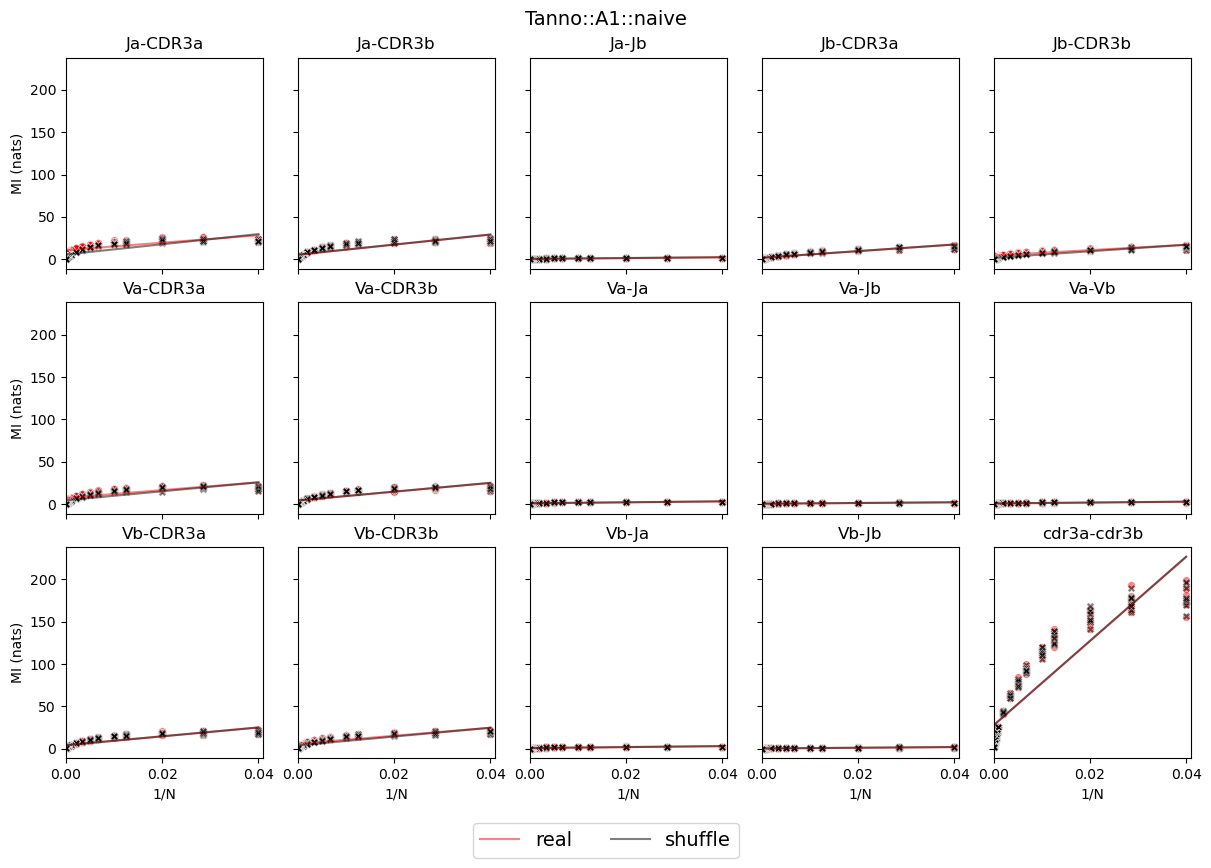

YLQPRTFLL


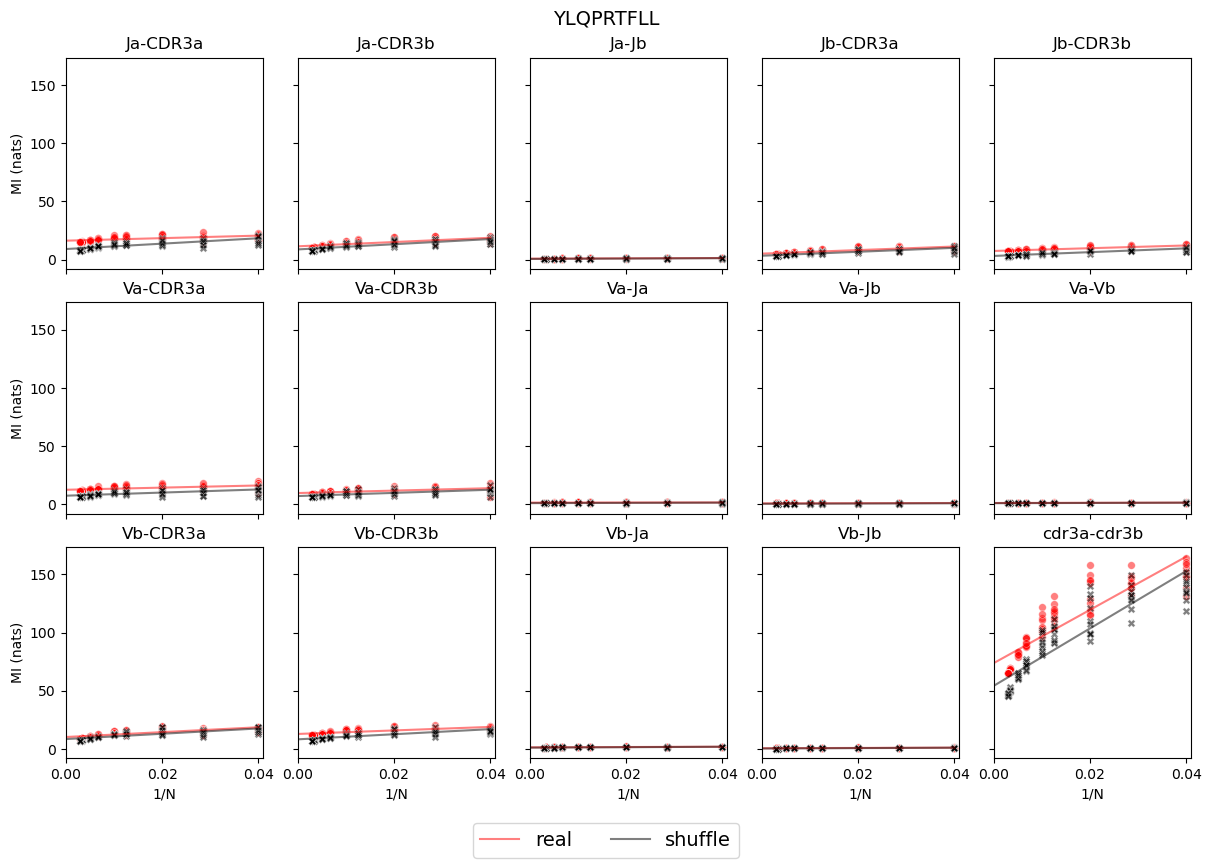

background


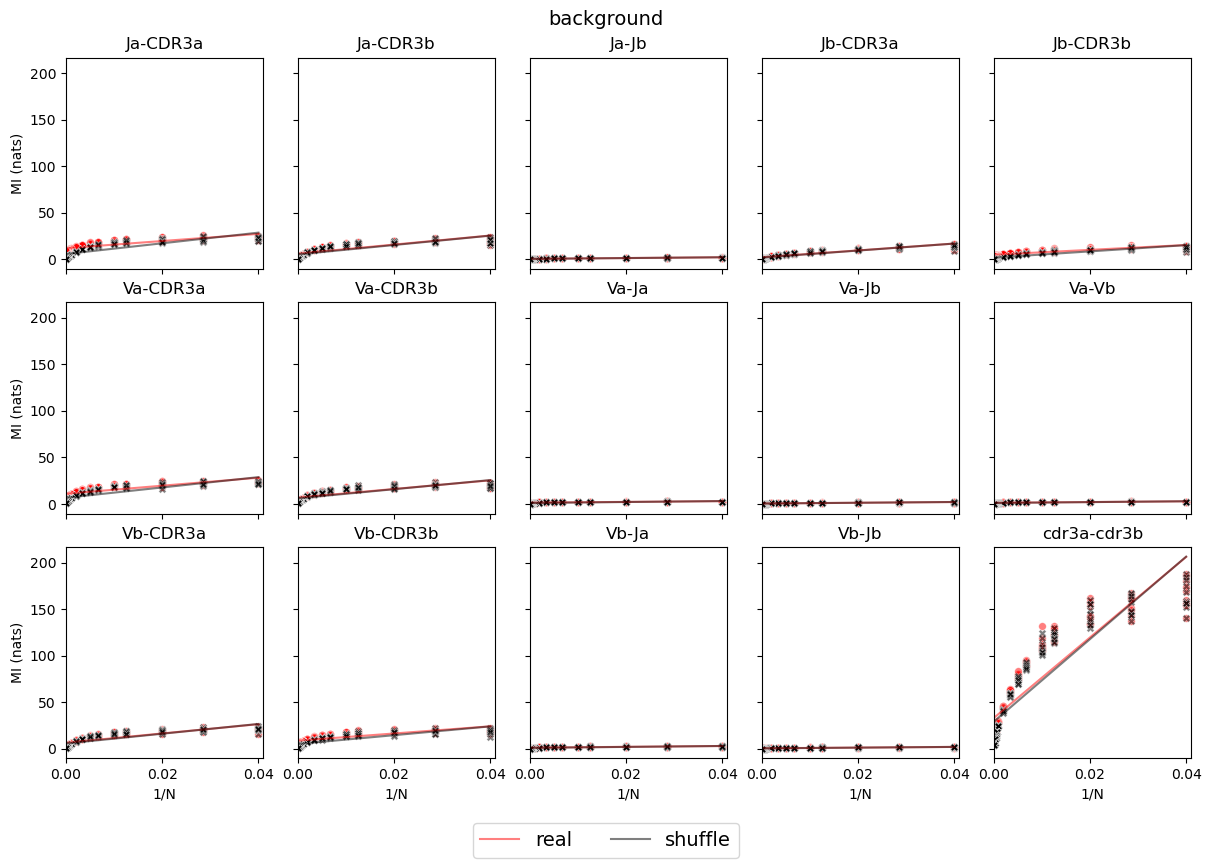

In [15]:
single_val = {}
s = MI2.shape
print(s)
print(MI2['type'].unique().tolist())
MI2_1 = MI2.dropna(subset='type')
print(MI2.shape)
assert s == MI2_1.shape

for ep in sorted(MI2['epitope'].unique().tolist()):
    print(ep)
    f, ax = plt.subplots(ncols=5, nrows=3, figsize=(12,8), sharex=True, sharey=True, constrained_layout=True)
    axs = ax.ravel()
    for i, t in enumerate(sorted(MI2['type'].unique().tolist())):
        # print(i, t)
        ss = MI2.loc[(MI2.epitope == ep) & (MI2.type == t)]
        # print(ss.sort_values(by='value', ascending=False))
        single_val[ep + '_' + t] = fit_linear(ss, t, axs[i])
        # print(single_val)
        axs[i].set_ylabel('')
        if i in [0,5,10]:
            axs[i].set_ylabel('MI (nats)')
        if i >= 10:
            axs[i].set_xlabel('1/N')
        
        h, l = axs[i].get_legend_handles_labels()
        axs[i].get_legend().remove()
    lgd = f.legend(handles = h, labels = l,
            bbox_to_anchor=(0.5, -0.01), loc='upper center', 
            ncol=2, prop={'size': 14})
    title = f.suptitle(ep, fontsize=14)
    if ep == 'GLCTLVAML':
        plt.savefig(f2 + 'MI_estimation_GLC_endpadding_w_studyspecific_shuffle_wdupl.png',
                    bbox_extra_artists=(lgd,title,), bbox_inches='tight')
    plt.show()

In [16]:
MI

25     \
type        Unnamed: 0                                                                    
cdr3a-cdr3b ELAGIGILTV                [147.22949467707411, 137.01286256321913, 170.2...   
            ELAGIGILTV_shuffle        [149.70558498987685, 137.80349669476115, 165.3...   
Va-Vb       ELAGIGILTV                [0.72477325422831, 0.524101208050448, 0.876309...   
            ELAGIGILTV_shuffle        [0.7383651771719416, 0.5795529824952437, 0.823...   
Ja-Jb       ELAGIGILTV                [1.804313535190778, 1.7352698378023508, 1.4513...   
...                                                                                 ...   
Vb-CDR3a    Tanno::A1::naive_shuffle  [19.703493178085562, 17.47135584556802, 20.690...   
Ja-CDR3b    Tanno::A1::naive          [19.98048645697729, 23.512088557209694, 21.938...   
            Tanno::A1::naive_shuffle  [20.035938231422083, 23.401185008320102, 21.93...   
Jb-CDR3a    Tanno::A1::naive          [16.878665814410667, 15.386031874183782, 14.51...   
            Tanno::A1::naive_shuffle  [17.23892818702365, 14.43601370581531, 14.8270...   

                                                                                  35     \
type        Unnamed: 0                                                                    
cdr3a-cdr3b ELAGIGILTV                [140.9928202432357, 136.65866540515015, 130.41...   
            ELAGIGILTV_shuffle        [136.41345592443417, 137.22567449744102, 132.8...   
Va-Vb       ELAGIGILTV                [0.5029940199556298, 0.9013217987335207, 0.671...   
            ELAGIGILTV_shuffle        [0.5029940199556296, 0.9655886724042415, 0.601...   
Ja-Jb       ELAGIGILTV                [1.768751313206483, 1.4104781289921404, 1.5006...   
...                                                                                 ...   
Vb-CDR3a    Tanno::A1::naive_shuffle  [16.265610733961523, 21.187424770396543, 17.15...   
Ja-CDR3b    Tanno::A1::naive          [20.880629991981756, 20.545649748784605, 24.18...   
            Tanno::A1::naive_shuffle  [20.381362443014844, 19.951523594018937, 23.89...   
Jb-CDR3a    Tanno::A1::naive          [13.21598832814762, 14.141054024945678, 12.768...   
            Tanno::A1::naive_shuffle  [13.07831197971254, 13.85082296201534, 12.7614...   

                                                                                  50     \
type        Unnamed: 0                                                                    
cdr3a-cdr3b ELAGIGILTV                [115.4342059824015, 119.92774480049563, 125.56...   
            ELAGIGILTV_shuffle        [113.50624377300697, 118.6930980509267, 125.17...   
Va-Vb       ELAGIGILTV                [0.6957509182433519, 0.6580582197077287, 0.542...   
            ELAGIGILTV_shuffle        [0.7002242682929235, 0.6421817247414607, 0.637...   
Ja-Jb       ELAGIGILTV                [1.5985190542564465, 1.4833664232286377, 1.445...   
...                                                                                 ...   
Vb-CDR3a    Tanno::A1::naive_shuffle  [19.974017092903736, 17.5258487135666, 16.8070...   
Ja-CDR3b    Tanno::A1::naive          [24.042232533946528, 19.227053616286206, 20.83...   
            Tanno::A1::naive_shuffle  [23.820425436167344, 20.010358360013637, 19.99...   
Jb-CDR3a    Tanno::A1::naive          [11.90317187242751, 10.149334591060274, 10.517...   
            Tanno::A1::naive_shuffle  [11.612717217966173, 10.437942533081491, 10.54...   

                                                                                  80     \
type        Unnamed: 0                                                                    
cdr3a-cdr3b ELAGIGILTV                [99.59703712031306, 104.77906181598074, 103.03...   
            ELAGIGILTV_shuffle        [102.74350073190422, 101.26375394386702, 103.0...   
Va-Vb       ELAGIGILTV                [0.4759661496752545, 0.3107125567162439, 0.266...   
            ELAGIGILTV_shuffle        [0.5669719856829274, 0.26772418791782

In [17]:
MI = pd.DataFrame(single_val, index = ['real', 'shuffle']).T
MI.to_csv('data/output/mutual_info/estimated_mutual_info_all_epitopes_endpadding_w_studyspecific_shuffle_wdupl.csv')